In [1]:
!pip install pandas pyarrow matplotlib seaborn

## **Import libraries**

In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## **Load data**

In [3]:
DATA_PATH = './recommendation dataset/'

# Load data Items
items_df = pd.read_parquet(DATA_PATH + 'sales_pers.item_chunk_0.parquet')

# Load và gộp dữ liệu Users
user_files = glob.glob(DATA_PATH + 'sales_pers.user_chunk_*.parquet')
list_of_user_dfs = [pd.read_parquet(file) for file in user_files]
users_df = pd.concat(list_of_user_dfs, ignore_index=True)

# Load và gộp dữ liệu Lịch sử mua hàng
history_files = glob.glob(DATA_PATH + 'sales_pers.purchase_history_daily_chunk_*.parquet')
list_of_history_dfs = [pd.read_parquet(file) for file in history_files]
history_df = pd.concat(list_of_history_dfs, ignore_index=True)

print(f"Items DF: {items_df.shape}")
print(f"Users DF: {users_df.shape}")
print(f"History DF: {history_df.shape}")

Items DF: (27332, 34)
Users DF: (4573964, 18)
History DF: (35729825, 16)


## **Phân tích DataFrame**

In [4]:
def explore_dataframe(df, name):
    print(f"--- Phân tích DataFrame: {name} ---")
    # 1. Xem 5 dòng đầu tiên
    print("\n1. Dữ liệu mẫu (head):")
    print(df.head())

    # 2. Thông tin tổng quan (kiểu dữ liệu, số lượng non-null)
    print("\n2. Thông tin (info):")
    df.info()

    # 3. Thống kê mô tả cho các cột số
    print("\n3. Thống kê mô tả (describe):")
    print(df.describe())

    # 4. Kiểm tra giá trị thiếu (missing values)
    print("\n4. Số lượng giá trị thiếu:")
    print(df.isnull().sum())
    print("-" * 30 + "\n")

### **Phân tích Items**

In [5]:
explore_dataframe(items_df, "Items")

--- Phân tích DataFrame: Items ---

1. Dữ liệu mẫu (head):
    p_id        item_id        price  category_l1_id     category_l1  \
0  17065  0502020000004   99000.0000               1        Babycare   
1  72370  0010290040150   69000.0000            3292      Thời trang   
2  31154  0008010000015   45000.0000             351  Đồ chơi & Sách   
3  46123  0020010000094  401000.0000            2222              Tã   
4  46127  0020010000098  401000.0000            2222              Tã   

   category_l2_id         category_l2  category_l3_id  \
0              35  Bình sữa, phụ kiện            7050   
1            3958      Cơ cấu hàng cũ            7007   
2            2033                0-1Y            2118   
3            2272             Merries            2275   
4            2272             Merries            2275   

                     category_l3  category_id  ...       item_type  \
0                         Núm ty         7058  ...  Không xác định   
1  Thời trang bé trai, bé

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27332 entries, 0 to 27331
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   p_id                27332 non-null  int32         
 1   item_id             27332 non-null  object        
 2   price               27332 non-null  object        
 3   category_l1_id      27332 non-null  int32         
 4   category_l1         27332 non-null  object        
 5   category_l2_id      27332 non-null  int32         
 6   category_l2         27332 non-null  object        
 7   category_l3_id      27332 non-null  int32         
 8   category_l3         27332 non-null  object        
 9   category_id         27332 non-null  int32         
 10  category            27332 non-null  object        
 11  description         27332 non-null  object        
 12  brand               27332 non-null  object        
 13  manufacturer        27332 non-null  object    

### Nhận xét:

* Cột `price` và `gp` đang có kiểu dữ liệu là `object` (chuỗi), trong khi chúng phải là số (`float` hoặc `int`) để tính toán. Đây là lý do tại sao chúng không xuất hiện trong phần `describe()`.

* Cột `weight` và `sync_error_message` trống hoàn toàn (27332 giá trị thiếu). Chúng không mang lại thông tin gì và có thể xóa đi.

* Cột `sync_status_id`, `last_sync_date`, và `description_new` có một số giá trị thiếu. Các cột `sync_*` có vẻ là dữ liệu hệ thống, có thể không cần thiết cho việc xây dựng mô hình gợi ý.

* Nhiều cột như `color`, `size`, `origin` chứa giá trị chuỗi "Không xác định". Đây thực chất là một dạng giá trị thiếu nhưng không được `pandas` nhận diện là `NaN`.

### **Phân tích Users**

In [6]:
explore_dataframe(users_df, "Users")

--- Phân tích DataFrame: Users ---

1. Dữ liệu mẫu (head):
   customer_id gender  location     province membership   timestamp  \
0        14732    Nam       155  Hồ Chí Minh   Standard  1306357911   
1        15126     Nữ       300  Hồ Chí Minh   Standard  1306357911   
2        29718     Nữ       157      Bến Tre   Standard  1312126692   
3        30077     Nữ        53  Hồ Chí Minh   Standard  1314302782   
4        30085     Nữ       660  Hồ Chí Minh   Standard  1314310024   

             created_date               updated_date  sync_status_id  \
0 2011-05-25 21:11:51.677 2025-07-07 15:33:10.201316             2.0   
1 2011-05-25 21:11:51.677 2025-07-07 15:33:10.201316             2.0   
2 2011-07-31 15:38:12.750 2025-07-07 15:33:10.201316             2.0   
3 2011-08-25 20:06:22.797 2025-07-07 15:33:10.201316             2.0   
4 2011-08-25 22:07:04.267 2025-07-07 15:33:10.201316             2.0   

              last_sync_date sync_error_message                   region  \
0 202

### Nhận xét:

* Cột `timestamp` và `install_date` đang là kiểu `int64`. Đây là định dạng **Unix timestamp**, cần được chuyển đổi sang `datetime` để có thể phân tích theo thời gian (ví dụ: khách hàng này đã tham gia được bao lâu).

* Tương tự `items_df`, cột `sync_error_message` hoàn toàn trống.

* Cột `user_id` là một chuỗi hash dài, đây sẽ là **khóa chính** để kết nối với `history_df`. Cột `customer_id` là một định danh khác. Cần kiểm tra xem có sự trùng lặp giữa hai cột này không.

### **Phân tích Purchase History**

In [7]:
explore_dataframe(history_df, "History")

--- Phân tích DataFrame: History ---

1. Dữ liệu mẫu (head):
    timestamp                                            user_id  \
0  1717185910  e9dd339daf179ce86716f0ce734e1dfa850a7e81481076...   
1  1717182347  76eeb2afca779fba0bd988a8910074218a18481f25eeeb...   
2  1717184923  52c68eecb3ca8241d104867d96361634c830d8709593e0...   
3  1717096117  33a6209df085b3340d77160abe4599dbc829a6c8ac0988...   
4  1717186942  49ff163495595f68a3839a2a292963fdc5b971f3f26659...   

         item_id event_type event_value        price  date_key  quantity  \
0  6847000000002   Purchase      1.0000   45000.0000  20240531         1   
1  1371000000005   Purchase      1.0000   20000.0000  20240531         1   
2  6767000000002   Purchase      1.0000  265000.0000  20240531         1   
3  4373000000001   Purchase      1.0000  125000.0000  20240530         1   
4  3880000000001   Purchase      2.0000   60000.0000  20240531         2   

   customer_id            created_date            updated_date   channel 

### Nhận xét:

* Giống như `items_df`, các cột `price`, `event_value`, `discount` đang là `object`. Đây là vấn đề nghiêm trọng nhất cần khắc phục.

* Cột `date_key` là số nguyên (ví dụ: `20240531`), cần chuyển sang `datetime`. Cột `timestamp` cũng là **Unix timestamp**.

* Cột `event_type` rất đáng chú ý. Output chỉ cho thấy giá trị 'Purchase', nhưng có thể có các loại sự kiện khác như 'view', 'add_to_cart'. Việc này sẽ quyết định bài toán của bạn là dự đoán lượt mua hay chỉ đơn giản là gợi ý sản phẩm.

* Báo cáo `isnull().sum()` không có giá trị thiếu nào. Điều này khá tốt, nhưng cũng nên cẩn thận kiểm tra các giá trị như chuỗi rỗng `''` hoặc các giá trị bất thường khác.

# **Phân tích đơn biến**

## **Dữ liệu Items**


### **Biểu đồ 1: Đặc trưng số**

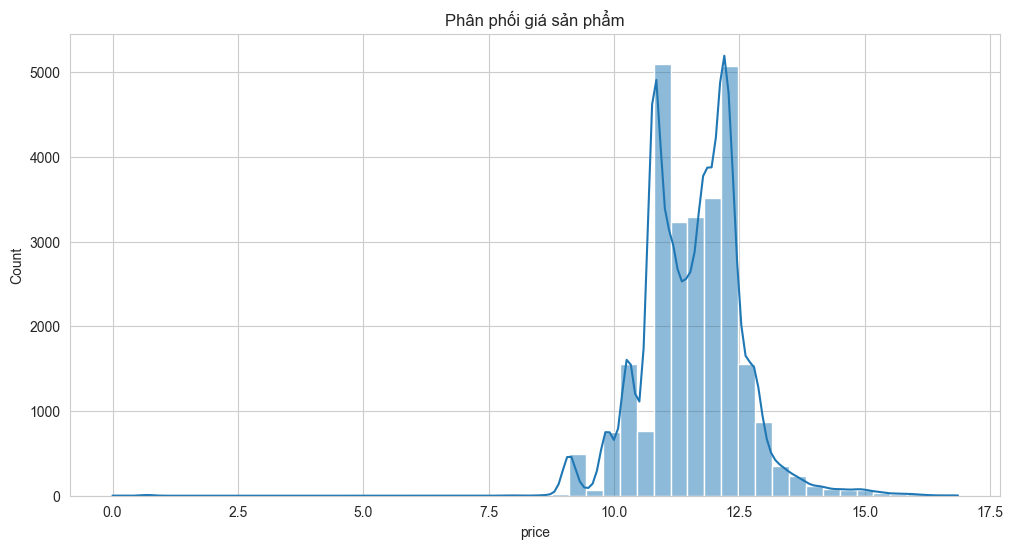

In [8]:
items_df['price'] = items_df['price'].astype(float)

log_price = np.log1p(items_df['price'])

sns.histplot(log_price, kde=True, bins=50)
plt.title('Phân phối giá sản phẩm')
plt.show()

### **Biểu đồ 2: Đặc trưng phân loại chính**

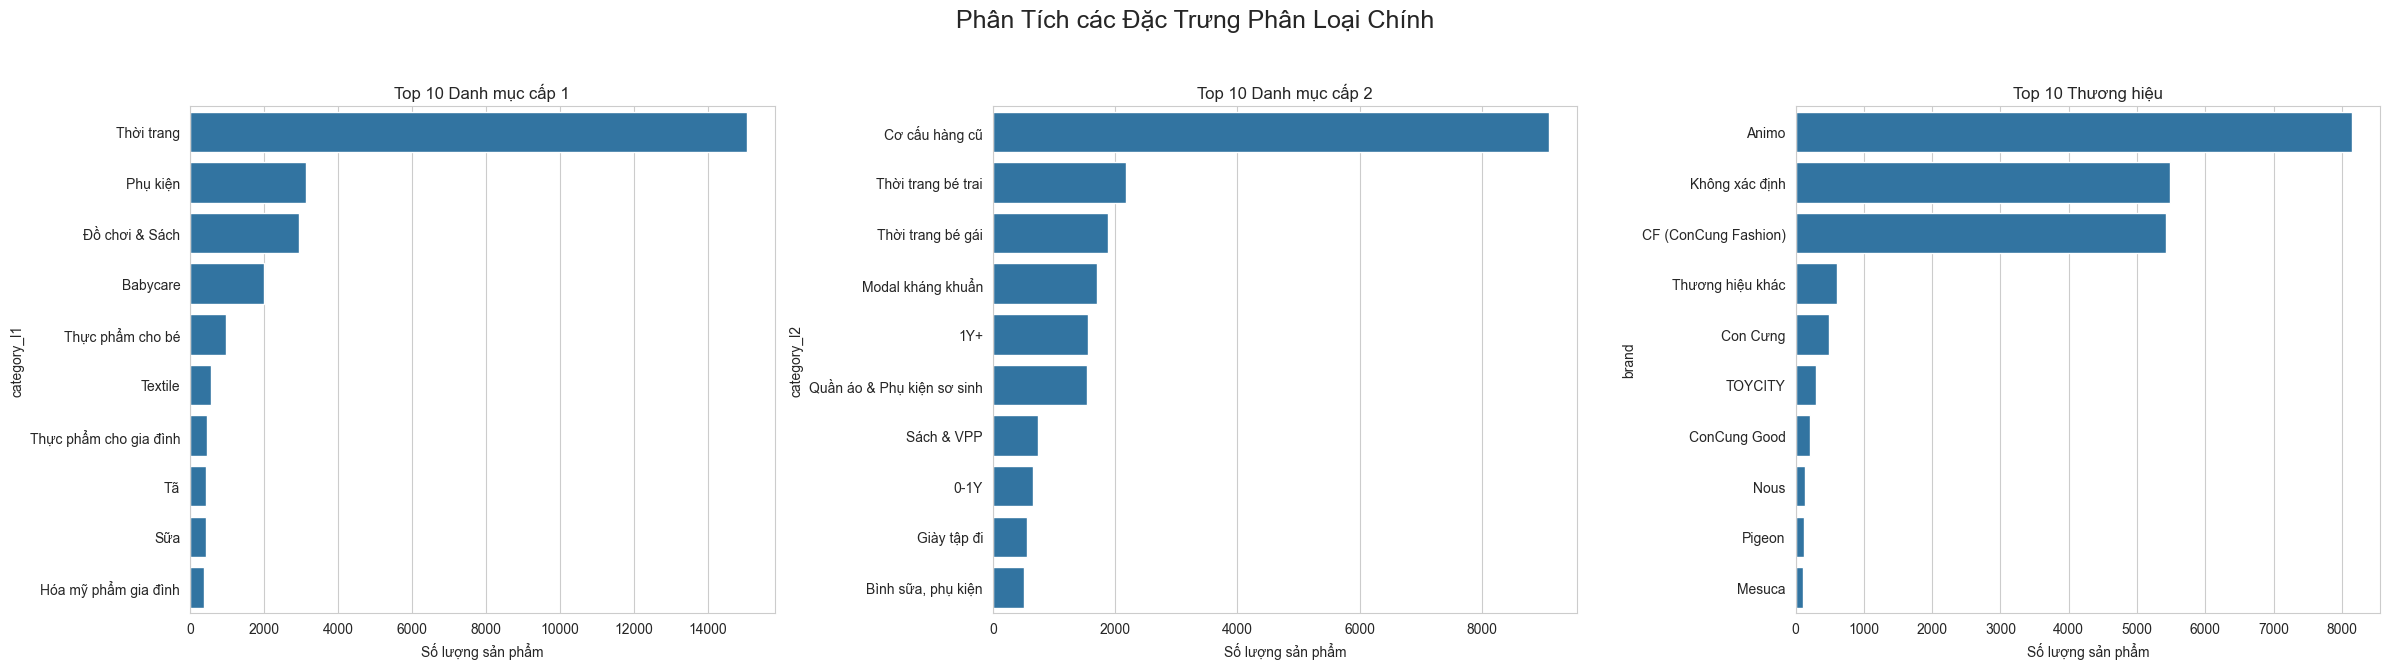

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Phân Tích các Đặc Trưng Phân Loại Chính', fontsize=18)

# Category L1
cat1_counts = items_df['category_l1'].value_counts().nlargest(10)
sns.barplot(x=cat1_counts.values, y=cat1_counts.index, ax=axes[0], orient='h')
axes[0].set_title('Top 10 Danh mục cấp 1')
axes[0].set_xlabel('Số lượng sản phẩm')

# Category L2
cat2_counts = items_df['category_l2'].value_counts().nlargest(10)
sns.barplot(x=cat2_counts.values, y=cat2_counts.index, ax=axes[1], orient='h')
axes[1].set_title('Top 10 Danh mục cấp 2')
axes[1].set_xlabel('Số lượng sản phẩm')

# Brand
brand_counts = items_df['brand'].value_counts().nlargest(10)
sns.barplot(x=brand_counts.values, y=brand_counts.index, ax=axes[2], orient='h')
axes[2].set_title('Top 10 Thương hiệu')
axes[2].set_xlabel('Số lượng sản phẩm')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Biểu đồ 3: Đặc trưng thuộc tính sản phẩm**

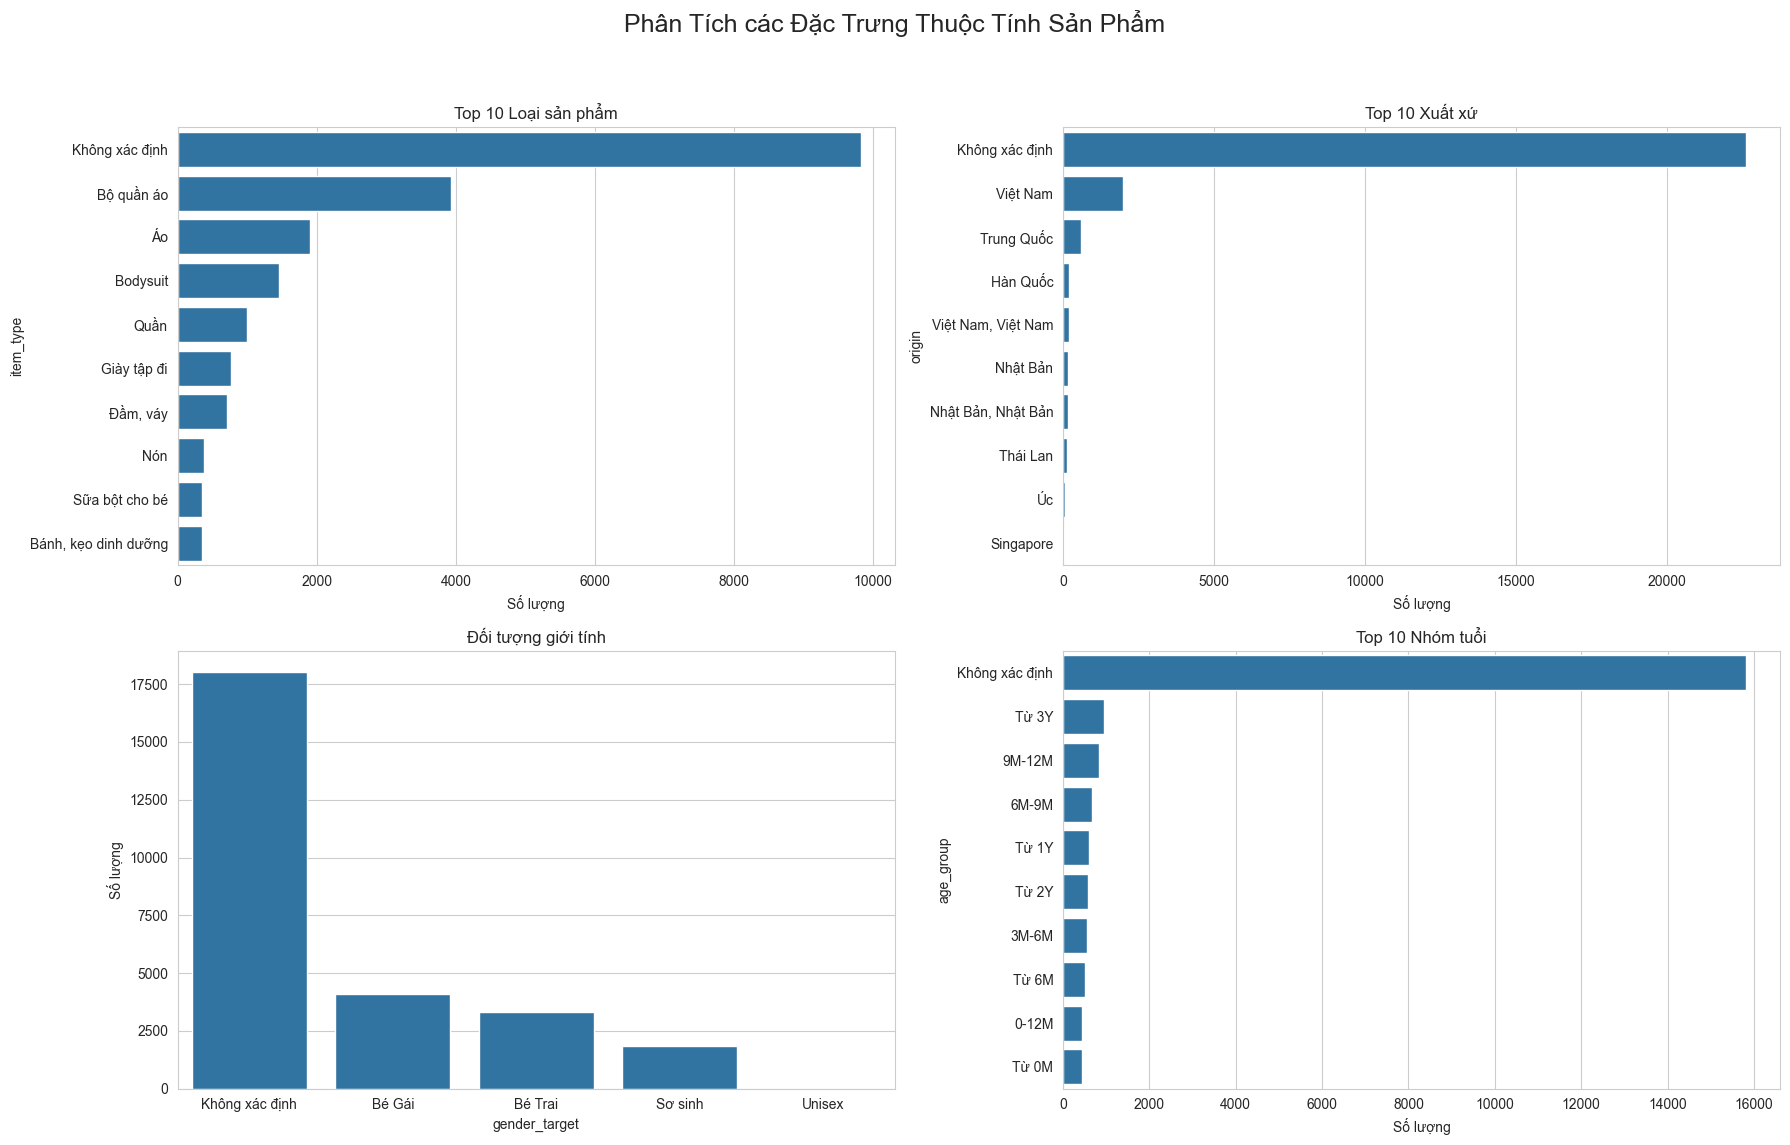

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Phân Tích các Đặc Trưng Thuộc Tính Sản Phẩm', fontsize=18)

# Item Type
item_type_counts = items_df['item_type'].value_counts().nlargest(10)
sns.barplot(x=item_type_counts.values, y=item_type_counts.index, ax=axes[0, 0], orient='h')
axes[0, 0].set_title('Top 10 Loại sản phẩm')
axes[0, 0].set_xlabel('Số lượng')

# Origin
origin_counts = items_df['origin'].value_counts().nlargest(10)
sns.barplot(x=origin_counts.values, y=origin_counts.index, ax=axes[0, 1], orient='h')
axes[0, 1].set_title('Top 10 Xuất xứ')
axes[0, 1].set_xlabel('Số lượng')

# Gender Target
gender_counts = items_df['gender_target'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[1, 0])
axes[1, 0].set_title('Đối tượng giới tính')
axes[1, 0].set_ylabel('Số lượng')

# Age Group
age_counts = items_df['age_group'].value_counts().nlargest(10)
sns.barplot(x=age_counts.values, y=age_counts.index, ax=axes[1, 1], orient='h')
axes[1, 1].set_title('Top 10 Nhóm tuổi')
axes[1, 1].set_xlabel('Số lượng')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Biểu đồ 4: Đặc trưng trạng thái & Thời gian**

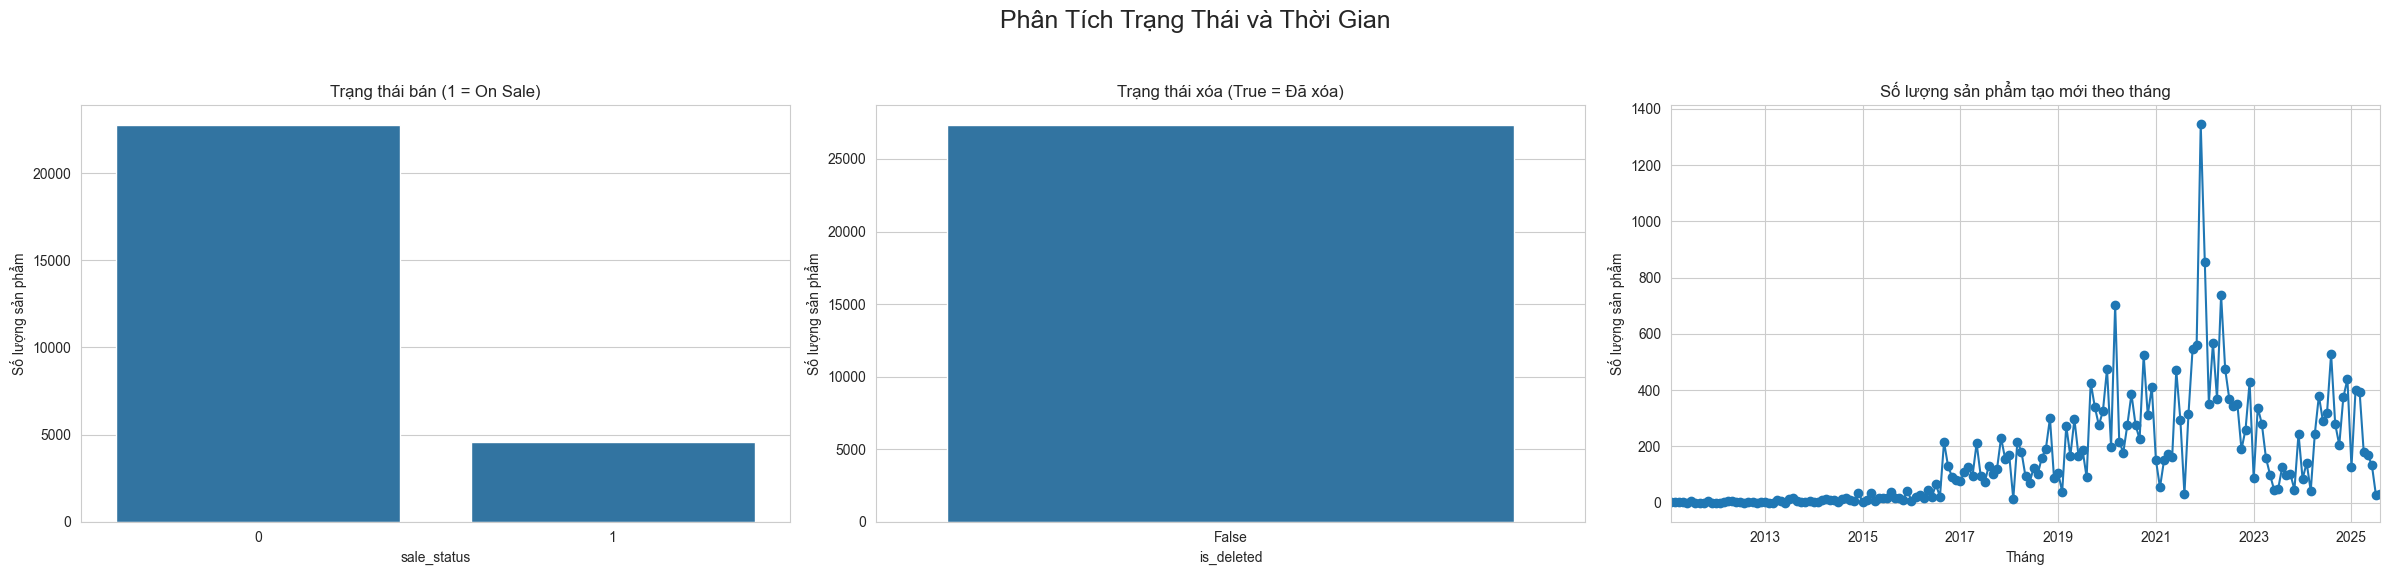

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Phân Tích Trạng Thái và Thời Gian', fontsize=18)

# Sale Status
sns.countplot(x='sale_status', data=items_df, ax=axes[0])
axes[0].set_title('Trạng thái bán (1 = On Sale)')
axes[0].set_ylabel('Số lượng sản phẩm')

# Is Deleted
sns.countplot(x='is_deleted', data=items_df, ax=axes[1])
axes[1].set_title('Trạng thái xóa (True = Đã xóa)')
axes[1].set_ylabel('Số lượng sản phẩm')

# Created Date
# Resample: nhóm dữ liệu theo tháng ('M') và đếm số lượng sản phẩm
items_by_month = items_df.set_index('created_date').resample('ME').size()
items_by_month.plot(kind='line', ax=axes[2], marker='o')
axes[2].set_title('Số lượng sản phẩm tạo mới theo tháng')
axes[2].set_xlabel('Tháng')
axes[2].set_ylabel('Số lượng sản phẩm')
plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## **Dữ liệu User**

### **Biểu đồ 1: Phân tích Nhân khẩu học**

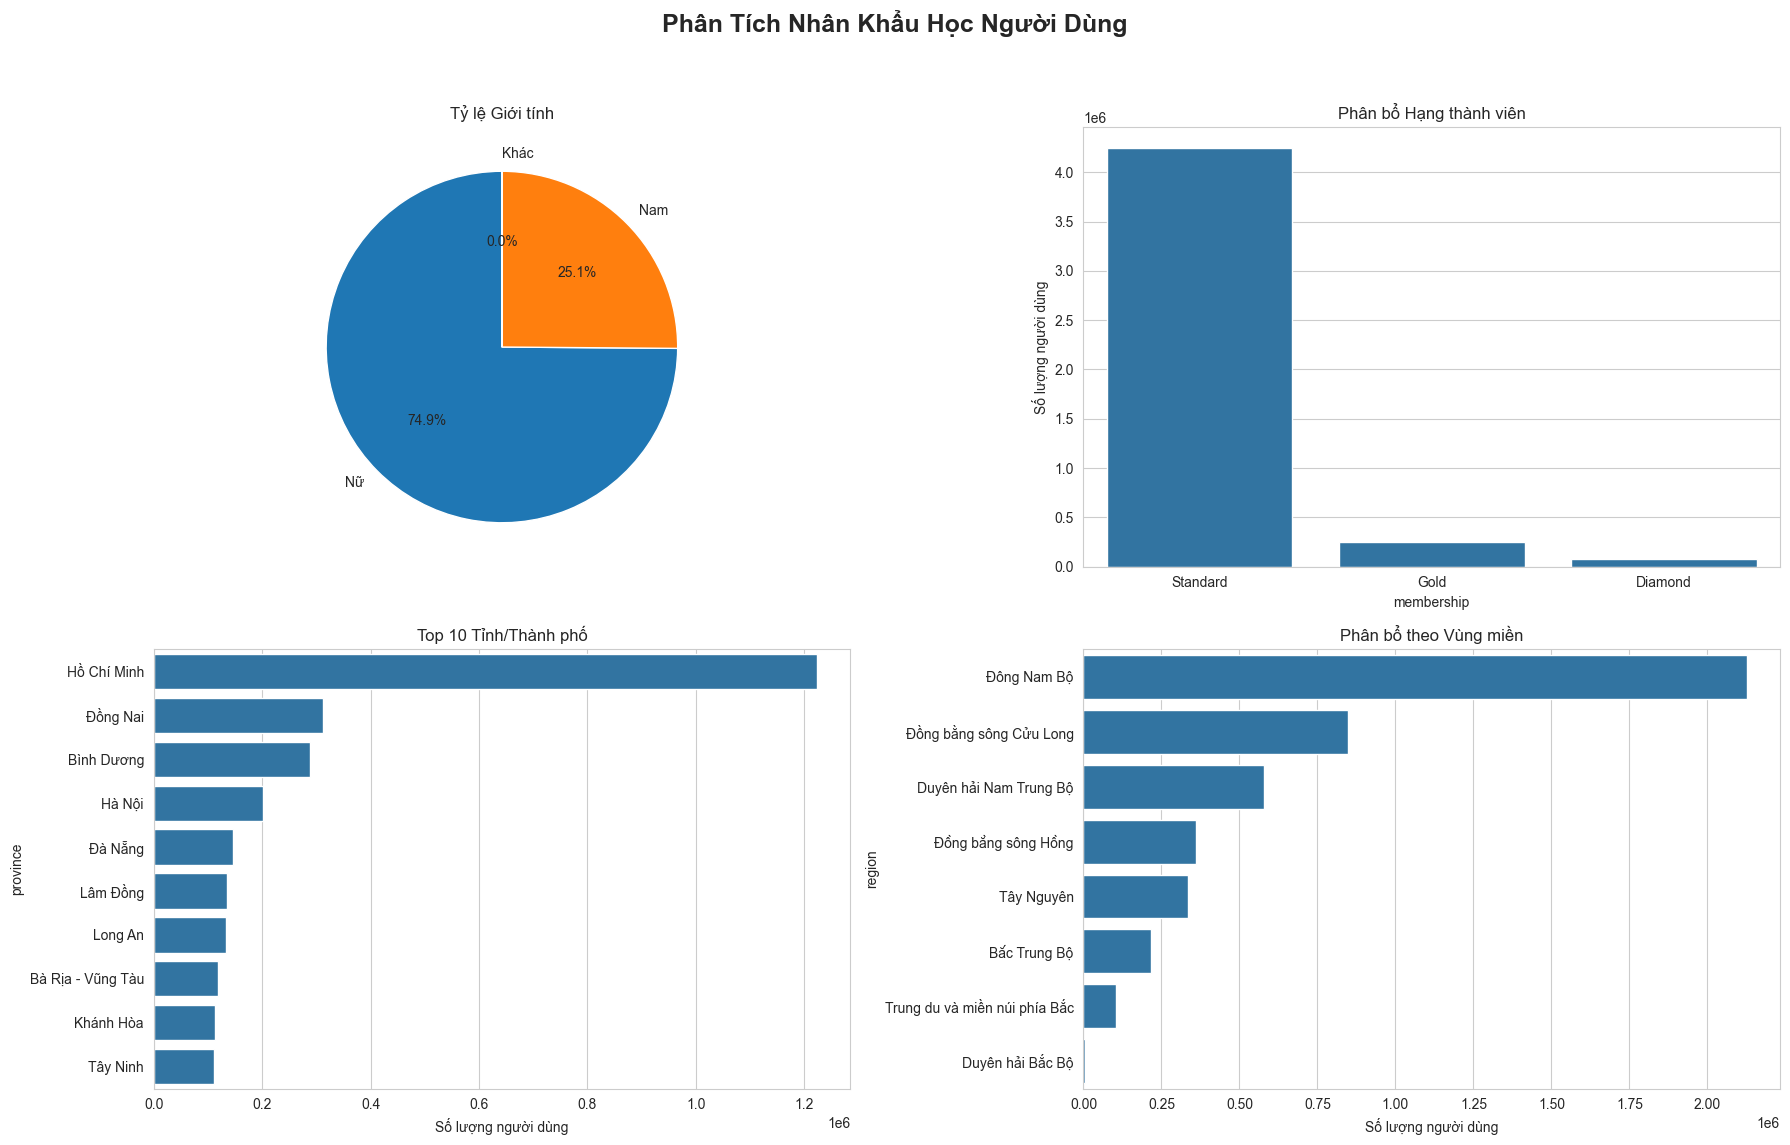

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Phân Tích Nhân Khẩu Học Người Dùng', fontsize=18, weight='bold')

# Gender
gender_counts = users_df['gender'].value_counts()
axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Tỷ lệ Giới tính')

# Membership
sns.countplot(x='membership', data=users_df, ax=axes[0, 1], order=users_df['membership'].value_counts().index)
axes[0, 1].set_title('Phân bổ Hạng thành viên')
axes[0, 1].set_ylabel('Số lượng người dùng')

# Top Provinces
top_provinces = users_df['province'].value_counts().nlargest(10)
sns.barplot(x=top_provinces.values, y=top_provinces.index, ax=axes[1, 0], orient='h')
axes[1, 0].set_title('Top 10 Tỉnh/Thành phố')
axes[1, 0].set_xlabel('Số lượng người dùng')

# Region
sns.countplot(y='region', data=users_df, ax=axes[1, 1], order=users_df['region'].value_counts().index)
axes[1, 1].set_title('Phân bổ theo Vùng miền')
axes[1, 1].set_xlabel('Số lượng người dùng')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### **Biểu đồ 2: Kênh & Trạng thái**

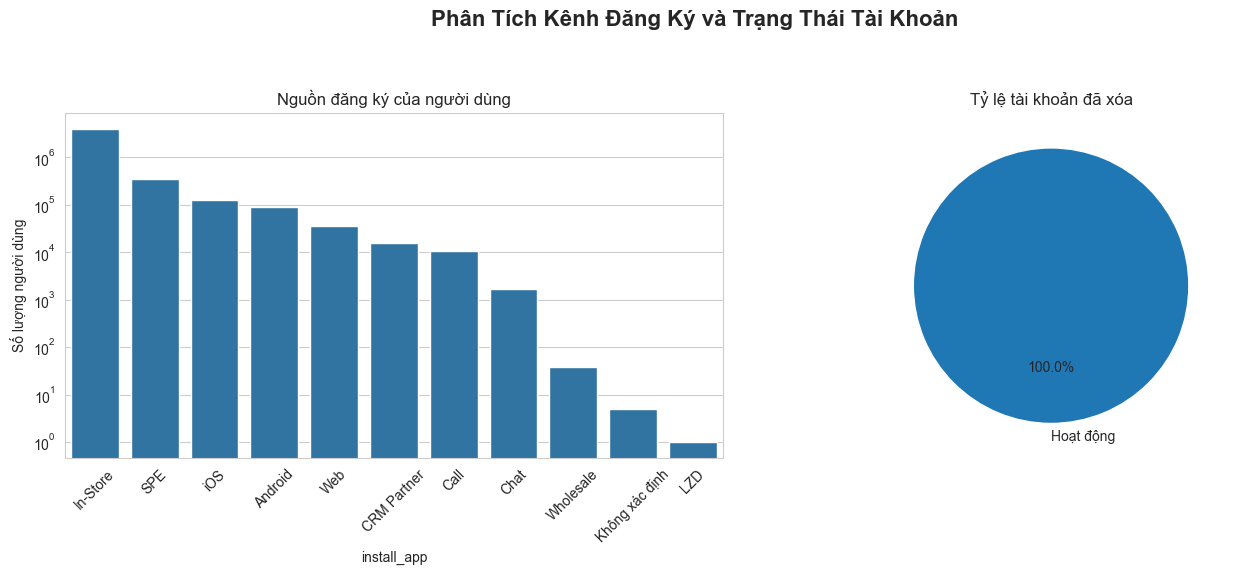

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phân Tích Kênh Đăng Ký và Trạng Thái Tài Khoản', fontsize=16, weight='bold')

# Vẽ biểu đồ cột
sns.countplot(x='install_app', data=users_df, ax=axes[0], order=users_df['install_app'].value_counts().index)
axes[0].set_title('Nguồn đăng ký của người dùng')
axes[0].set_ylabel('Số lượng người dùng')

axes[0].set_yscale('log')
# Xoay nhãn trục x cho dễ đọc
axes[0].tick_params(axis='x', rotation=45)

deleted_counts = users_df['is_deleted'].value_counts()

# Tạo nhãn một cách tự động
# Nếu index là True -> 'Đã xóa', nếu là False -> 'Hoạt động'
dynamic_labels = ['Đã xóa' if index else 'Hoạt động' for index in deleted_counts.index]

# Vẽ biểu đồ với các nhãn tự động này
axes[1].pie(deleted_counts, labels=dynamic_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ lệ tài khoản đã xóa')
# --------------------

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()



### **Biểu đồ 3: Tăng trưởng người dùng theo thời gian**

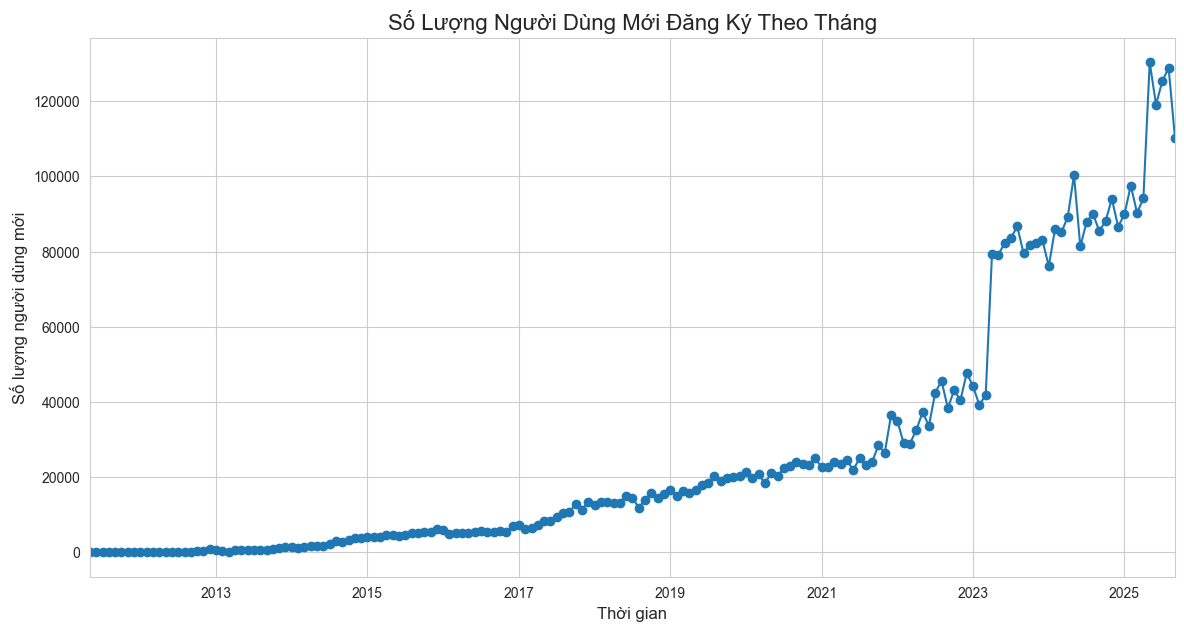

In [14]:

plt.figure(figsize=(14, 7))

# Nhóm người dùng theo tháng đăng ký và đếm số lượng
users_by_month = users_df.set_index('created_date').resample('ME').size()
users_by_month.plot(kind='line', marker='o', linestyle='-')

plt.title('Số Lượng Người Dùng Mới Đăng Ký Theo Tháng', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Số lượng người dùng mới', fontsize=12)
plt.grid(True)
plt.show()

## **Dữ liệu Purchase History**

In [15]:
history_df['price'] = pd.to_numeric(history_df['price'], errors='coerce').fillna(0)
history_df['discount'] = pd.to_numeric(history_df['discount'], errors='coerce').fillna(0)
history_df['created_date'] = pd.to_datetime(history_df['created_date'])
print("Làm sạch và chuyển đổi kiểu dữ liệu cho history_df thành công!")

Làm sạch và chuyển đổi kiểu dữ liệu cho history_df thành công!


### **Biểu đồ 1: Phân tích Giá trị Giao dịch**

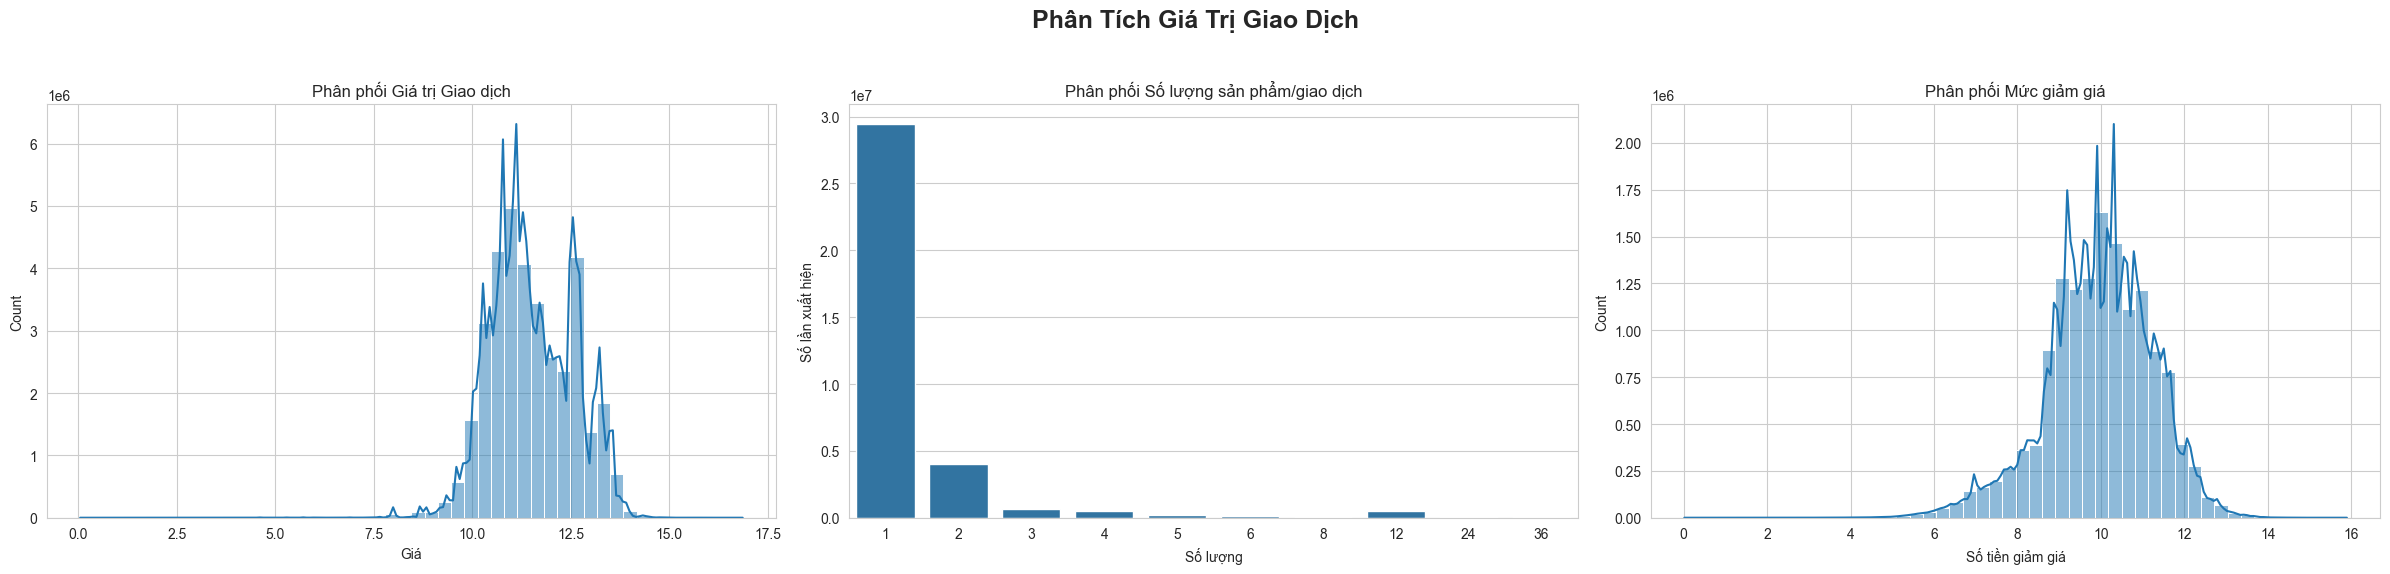

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Phân Tích Giá Trị Giao Dịch', fontsize=18, weight='bold')

# Price (Log-transformed)
sns.histplot(np.log1p(history_df['price']), ax=axes[0], kde=True, bins=50)
axes[0].set_title('Phân phối Giá trị Giao dịch')
axes[0].set_xlabel('Giá') # ĐÃ ĐỔI NHÃN

# Quantity
quantity_counts = history_df['quantity'].value_counts().nlargest(10)
sns.barplot(x=quantity_counts.index, y=quantity_counts.values, ax=axes[1])
axes[1].set_title('Phân phối Số lượng sản phẩm/giao dịch')
axes[1].set_xlabel('Số lượng')
axes[1].set_ylabel('Số lần xuất hiện')

# Discount (Log-transformed)
# Chỉ xét các giao dịch có giảm giá và áp dụng logarit
non_zero_discount_log = np.log1p(history_df[history_df['discount'] > 0]['discount'])
sns.histplot(non_zero_discount_log, ax=axes[2], kde=True, bins=50)
axes[2].set_title('Phân phối Mức giảm giá')
axes[2].set_xlabel('Số tiền giảm giá')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Biểu đồ 2: Phân tích Bối cảnh Giao dịch**

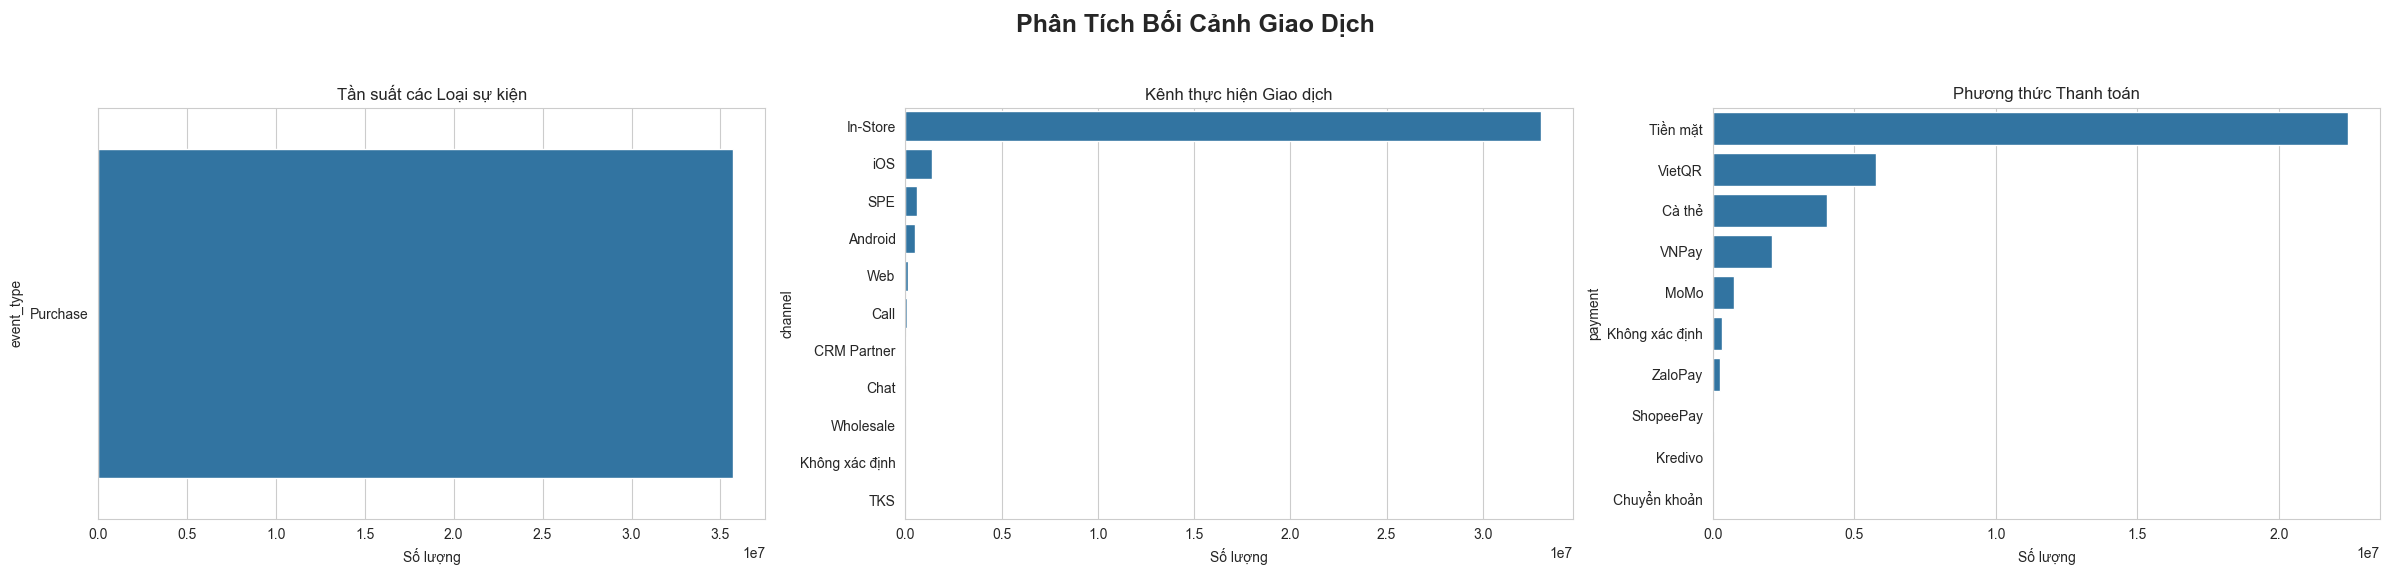

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Phân Tích Bối Cảnh Giao Dịch', fontsize=18, weight='bold')

# Event Type
sns.countplot(y='event_type', data=history_df, ax=axes[0], order=history_df['event_type'].value_counts().index)
axes[0].set_title('Tần suất các Loại sự kiện')
axes[0].set_xlabel('Số lượng')

# Channel
sns.countplot(y='channel', data=history_df, ax=axes[1], order=history_df['channel'].value_counts().index)
axes[1].set_title('Kênh thực hiện Giao dịch')
axes[1].set_xlabel('Số lượng')

# Payment Method
sns.countplot(y='payment', data=history_df, ax=axes[2], order=history_df['payment'].value_counts().index)
axes[2].set_title('Phương thức Thanh toán')
axes[2].set_xlabel('Số lượng')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Biểu đồ 3: Xu hướng Giao dịch theo Thời gian**

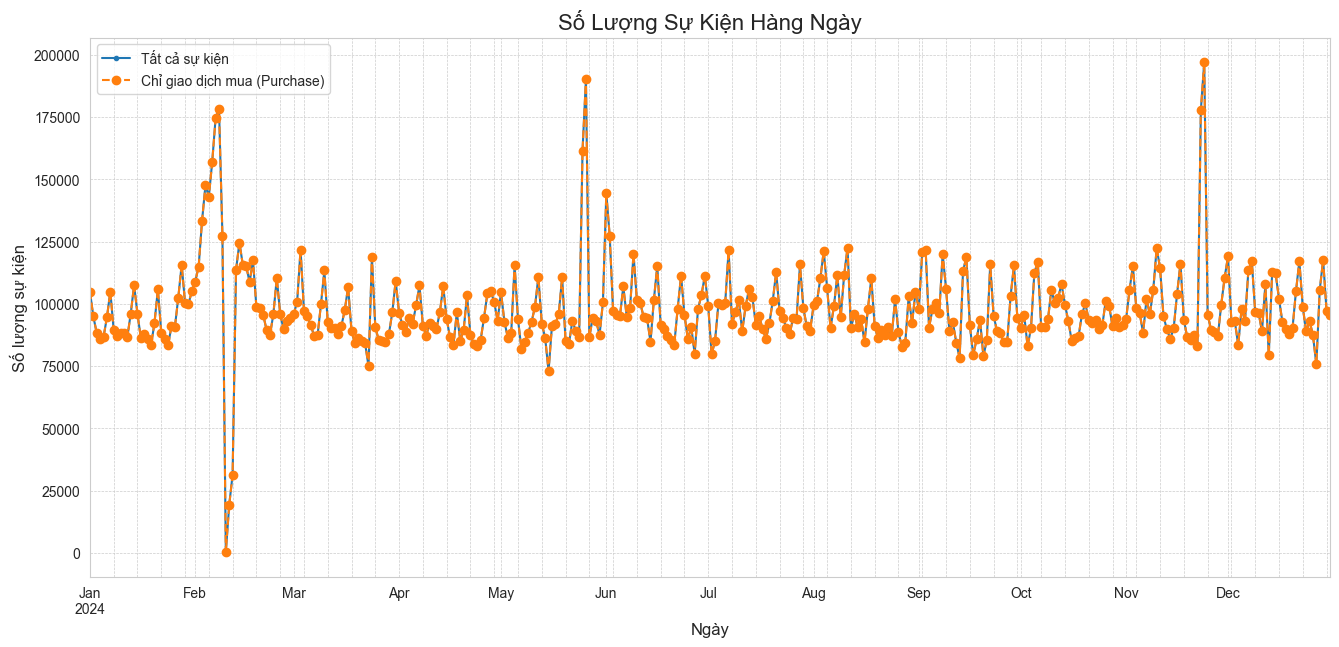

In [18]:
plt.figure(figsize=(16, 7))

# Nhóm các sự kiện theo ngày và đếm số lượng
events_by_day = history_df.set_index('created_date').resample('D').size()
events_by_day.plot(kind='line', marker='.', linestyle='-', label='Tất cả sự kiện')

# Nhóm các sự kiện 'Purchase' theo ngày
purchases_by_day = history_df[history_df['event_type']=='Purchase'].set_index('created_date').resample('D').size()
purchases_by_day.plot(kind='line', marker='o', linestyle='--', label='Chỉ giao dịch mua (Purchase)')


plt.title('Số Lượng Sự Kiện Hàng Ngày', fontsize=16)
plt.xlabel('Ngày', fontsize=12)
plt.ylabel('Số lượng sự kiện', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# **Phân tích đa biến**

In [19]:
# Gộp history với items
df_full = pd.merge(history_df, items_df, on='item_id', how='left')

# Gộp tiếp với users
df_full = pd.merge(df_full, users_df, on='user_id', how='left')

# Tính toán cột 'total_price' sử dụng 'price_x' (giá từ bảng history)
df_full['total_price'] = df_full['quantity'] * df_full['price_x']

df_full.drop(columns=['price_y'], inplace=True)
df_full.rename(columns={'price_x': 'price'}, inplace=True)


print("Gộp dữ liệu thành công! DataFrame tổng thể có dạng:")
# Bây giờ head() sẽ hiển thị cột 'price' (đã đổi tên) và 'total_price'
print(df_full.head())

Gộp dữ liệu thành công! DataFrame tổng thể có dạng:
   timestamp_x                                            user_id  \
0   1717185910  e9dd339daf179ce86716f0ce734e1dfa850a7e81481076...   
1   1717182347  76eeb2afca779fba0bd988a8910074218a18481f25eeeb...   
2   1717184923  52c68eecb3ca8241d104867d96361634c830d8709593e0...   
3   1717096117  33a6209df085b3340d77160abe4599dbc829a6c8ac0988...   
4   1717186942  49ff163495595f68a3839a2a292963fdc5b971f3f26659...   

         item_id event_type event_value     price  date_key  quantity  \
0  6847000000002   Purchase      1.0000   45000.0  20240531         1   
1  1371000000005   Purchase      1.0000   20000.0  20240531         1   
2  6767000000002   Purchase      1.0000  265000.0  20240531         1   
3  4373000000001   Purchase      1.0000  125000.0  20240530         1   
4  3880000000001   Purchase      2.0000   60000.0  20240531         2   

   customer_id_x          created_date_x  ... sync_status_id_y  \
0        2731206 2024-05-31 

In [20]:
df_full['day_of_week'] = df_full['created_date'].dt.day_name()
df_full['hour_of_day'] = df_full['created_date'].dt.hour

### **Phân tích giá trị giao dịch**

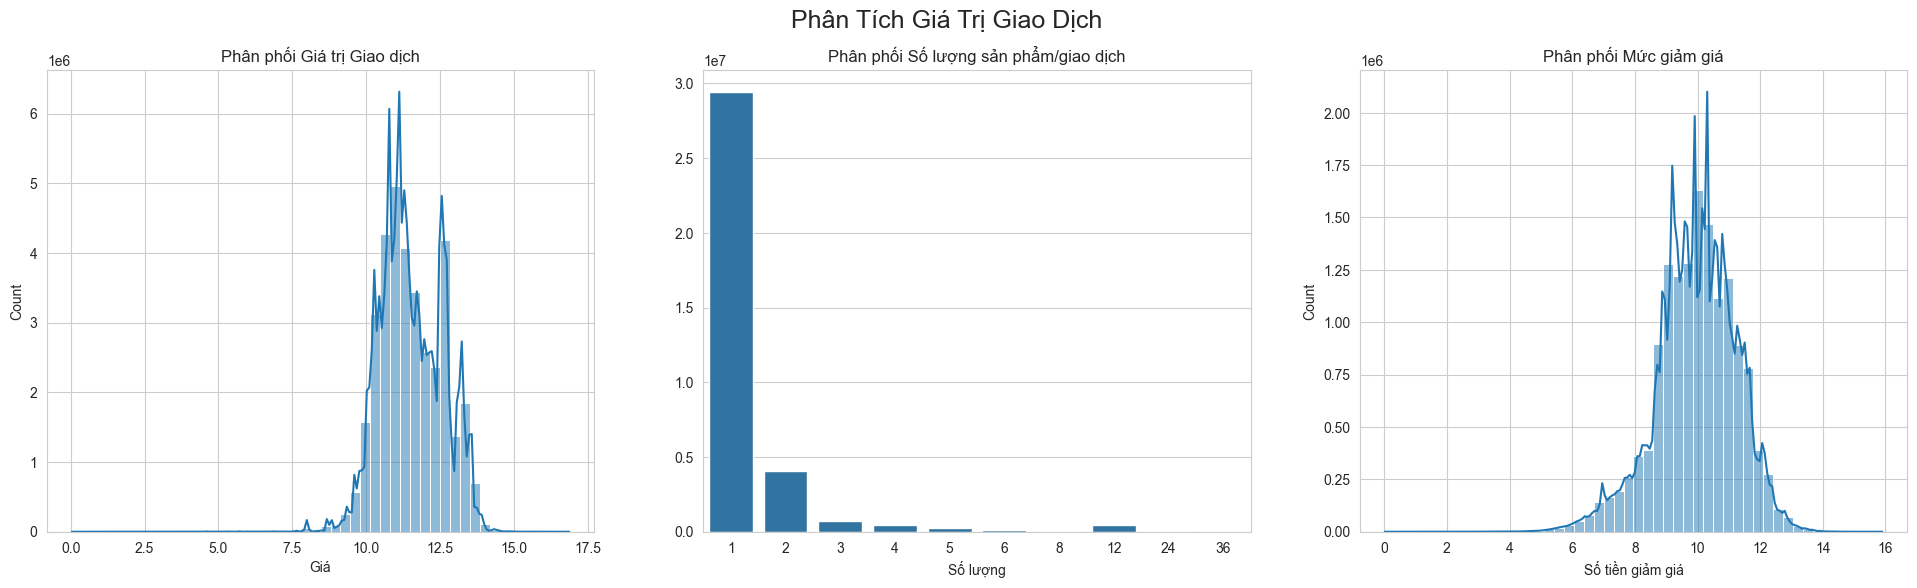

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Phân Tích Giá Trị Giao Dịch', fontsize=18)

# Price (Đã tốt)
sns.histplot(np.log1p(df_full['price']), ax=axes[0], kde=True, bins=50)
axes[0].set_title('Phân phối Giá trị Giao dịch')
axes[0].set_xlabel('Giá')

# Quantity (Giữ nguyên vì đây là các giá trị rời rạc nhỏ)
quantity_counts = df_full['quantity'].value_counts().nlargest(10)
sns.barplot(x=quantity_counts.index, y=quantity_counts.values, ax=axes[1])
axes[1].set_title('Phân phối Số lượng sản phẩm/giao dịch')
axes[1].set_xlabel('Số lượng')

# Discount (Áp dụng Log Transform)
non_zero_discount_log = np.log1p(df_full[df_full['discount'] > 0]['discount'])
sns.histplot(non_zero_discount_log, ax=axes[2], kde=True, bins=50)
axes[2].set_title('Phân phối Mức giảm giá')
axes[2].set_xlabel('Số tiền giảm giá')
plt.show()

### **Phân tích giá trị khách hàng**

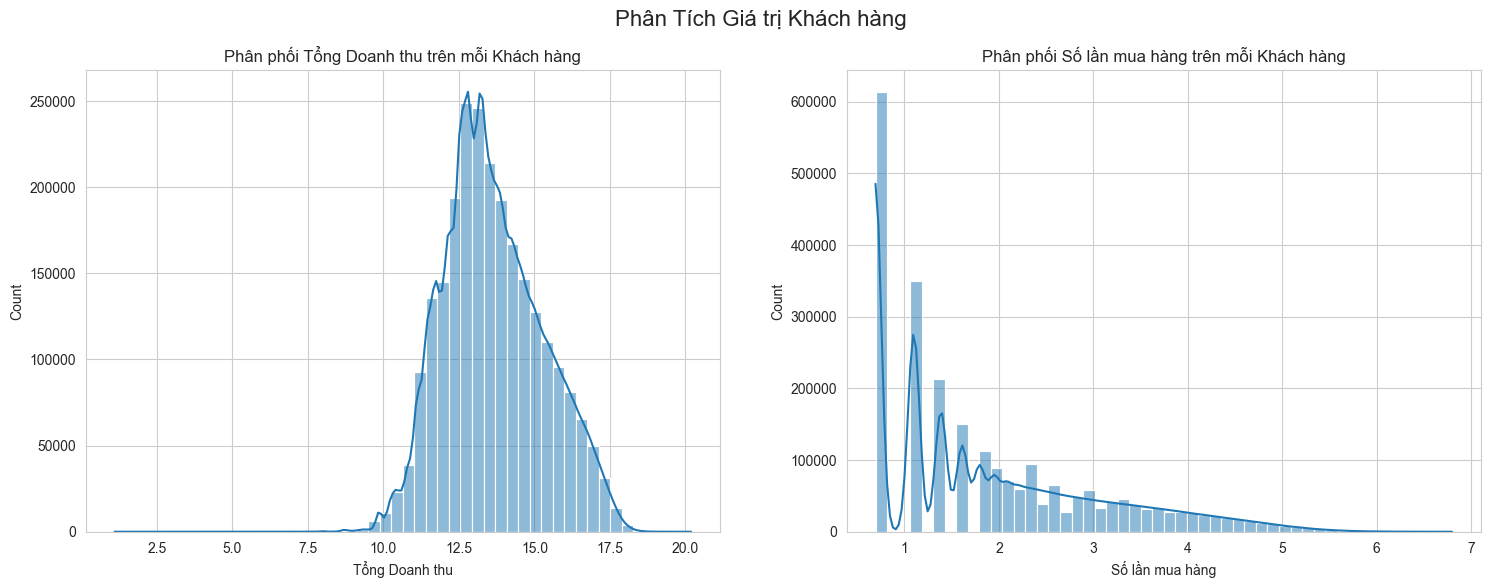

In [22]:
customer_value = df_full.groupby('user_id').agg(
    total_revenue=('total_price', 'sum'),
    purchase_count=('user_id', 'size')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Phân Tích Giá trị Khách hàng', fontsize=16)

# Total Revenue (Áp dụng Log Transform)
sns.histplot(np.log1p(customer_value['total_revenue']), bins=50, ax=axes[0], kde=True)
axes[0].set_title('Phân phối Tổng Doanh thu trên mỗi Khách hàng')
axes[0].set_xlabel('Tổng Doanh thu')

# Purchase Count (Áp dụng Log Transform)
sns.histplot(np.log1p(customer_value['purchase_count']), bins=50, ax=axes[1], kde=True)
axes[1].set_title('Phân phối Số lần mua hàng trên mỗi Khách hàng')
axes[1].set_xlabel('Số lần mua hàng')
plt.show()

### **Phân tích hiệu suất danh mục**

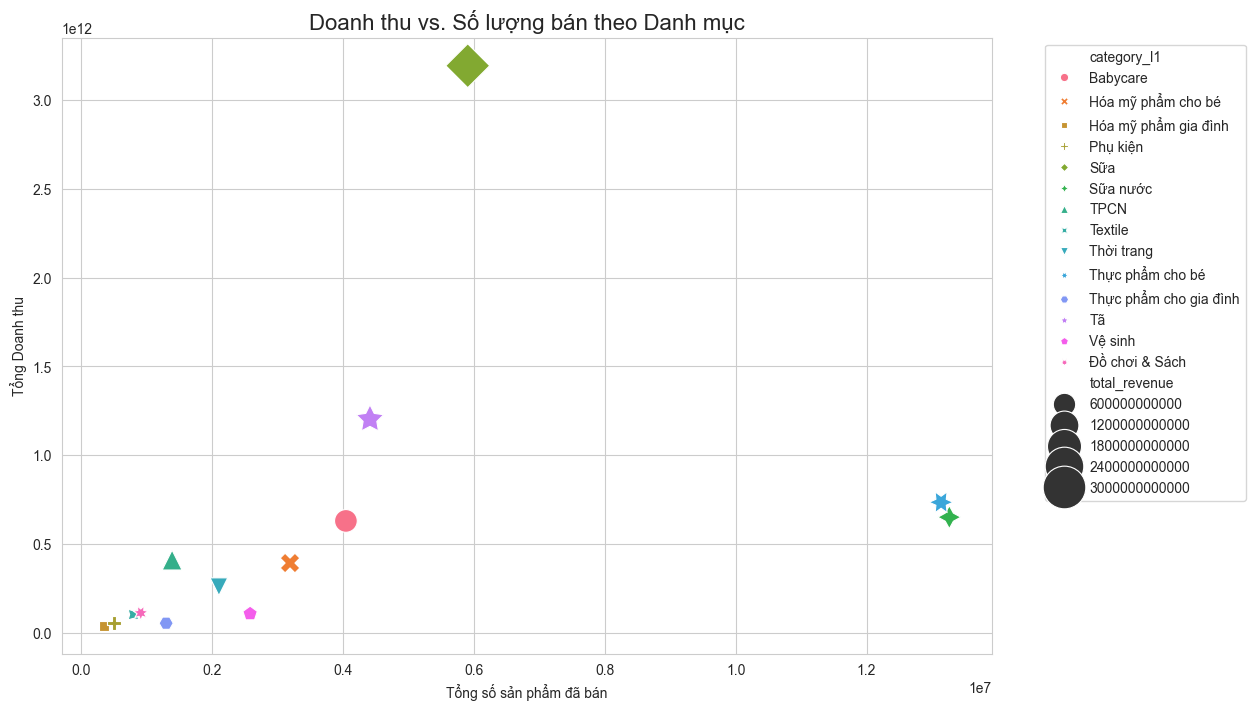

In [23]:
category_performance = df_full.groupby('category_l1').agg(
    total_revenue=('total_price', 'sum'),
    items_sold=('quantity', 'sum')
).reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=category_performance, x='items_sold', y='total_revenue', hue='category_l1', size='total_revenue', sizes=(100, 1000), style='category_l1')
plt.title('Doanh thu vs. Số lượng bán theo Danh mục', fontsize=16)
plt.xlabel('Tổng số sản phẩm đã bán')
plt.ylabel('Tổng Doanh thu')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### **Phân tích giỏ hàng**

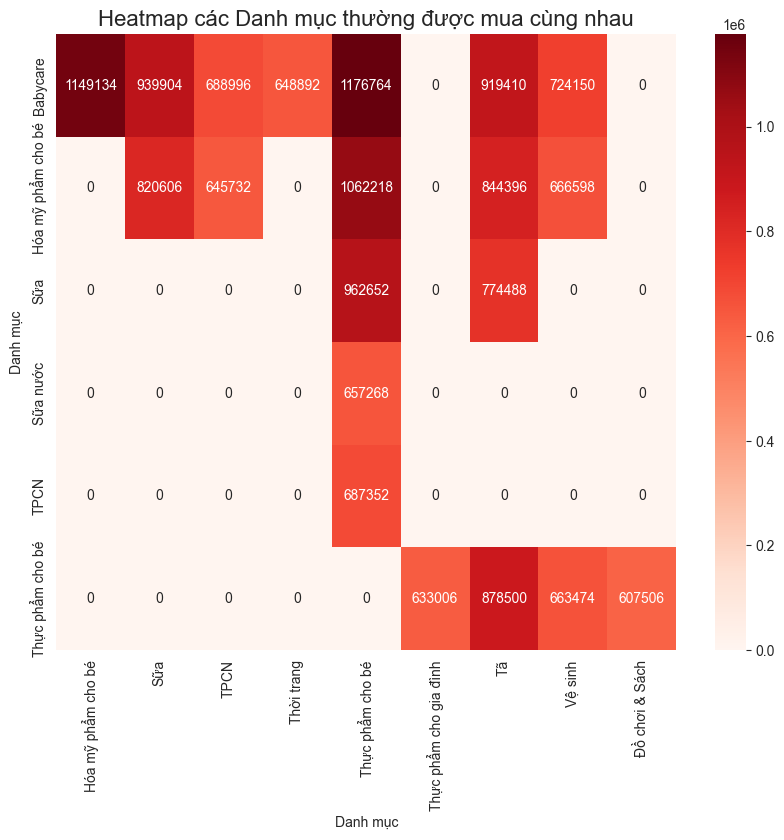

In [24]:
baskets = df_full.groupby(['user_id', 'created_date'])['category_l1'].apply(list).reset_index(name='categories')

from itertools import permutations
from collections import Counter

# Đếm các cặp danh mục xuất hiện cùng nhau
co_purchase_counts = Counter()
for row in baskets['categories']:
    # Loại bỏ các danh mục trùng lặp trong một giỏ hàng
    unique_categories = list(set(row))
    if len(unique_categories) > 1:
        # Tạo tất cả các cặp có thể có và sắp xếp để (A,B) giống (B,A)
        pairs = permutations(unique_categories, 2)
        sorted_pairs = [tuple(sorted(p)) for p in pairs]
        co_purchase_counts.update(sorted_pairs)

# Chuyển thành DataFrame để vẽ heatmap
co_purchase_df = pd.DataFrame(co_purchase_counts.most_common(20), columns=['pair', 'count'])
co_purchase_df[['cat1', 'cat2']] = pd.DataFrame(co_purchase_df['pair'].tolist(), index=co_purchase_df.index)
pivot_df = co_purchase_df.pivot_table(index='cat1', columns='cat2', values='count').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="Reds")
plt.title('Heatmap các Danh mục thường được mua cùng nhau', fontsize=16)
plt.xlabel('Danh mục')
plt.ylabel('Danh mục')
plt.show()

### **Phân tích thời gian mua sắm**

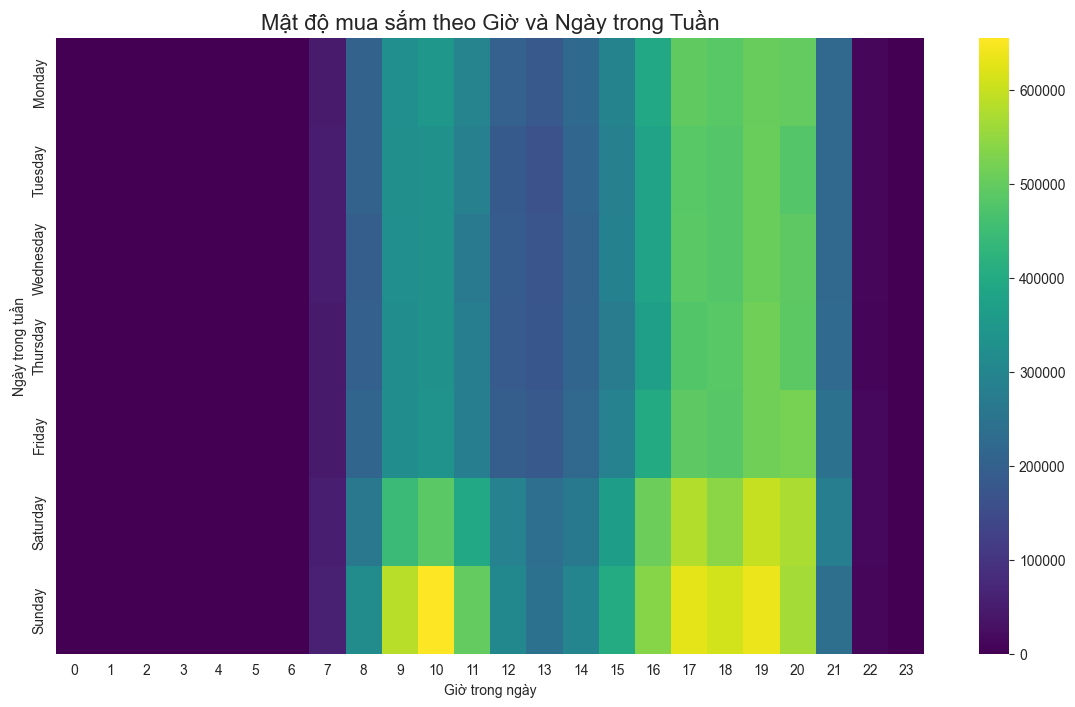

In [25]:
# Tạo bảng heatmap theo Ngày trong tuần và Giờ trong ngày
day_hour_counts = df_full.groupby(['day_of_week', 'hour_of_day']).size().unstack(fill_value=0)
# Sắp xếp lại thứ tự ngày trong tuần
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_hour_counts = day_hour_counts.reindex(day_order)

plt.figure(figsize=(14, 8))
sns.heatmap(day_hour_counts, cmap='viridis')
plt.title('Mật độ mua sắm theo Giờ và Ngày trong Tuần', fontsize=16)
plt.xlabel('Giờ trong ngày')
plt.ylabel('Ngày trong tuần')
plt.show()

### **Mối quan hệ giữa giá và lợi nhuận**

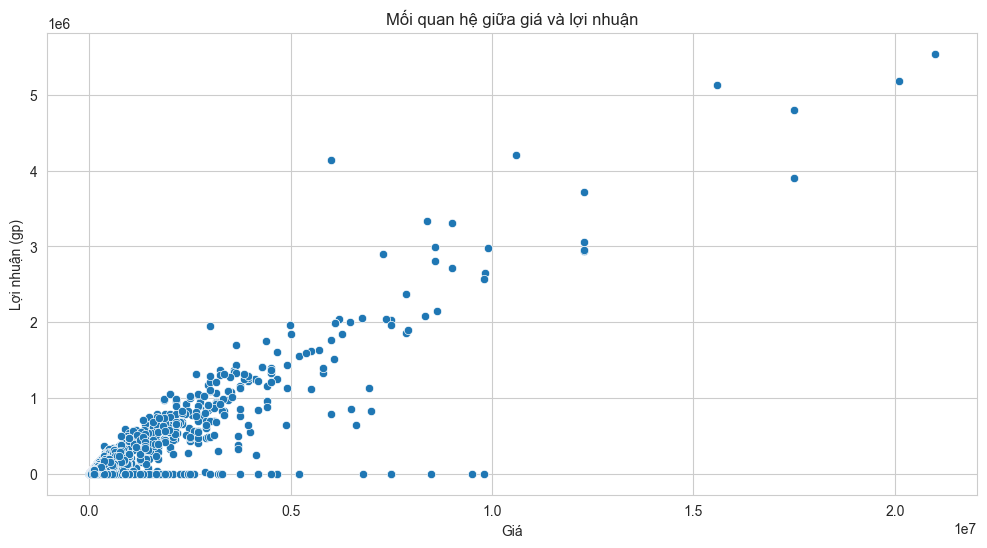

In [26]:
sns.scatterplot(data=items_df, x='price', y='gp')
plt.title('Mối quan hệ giữa giá và lợi nhuận')
plt.xlabel('Giá')
plt.ylabel('Lợi nhuận (gp)')
plt.show()

### **Giá trung bình theo danh mục**

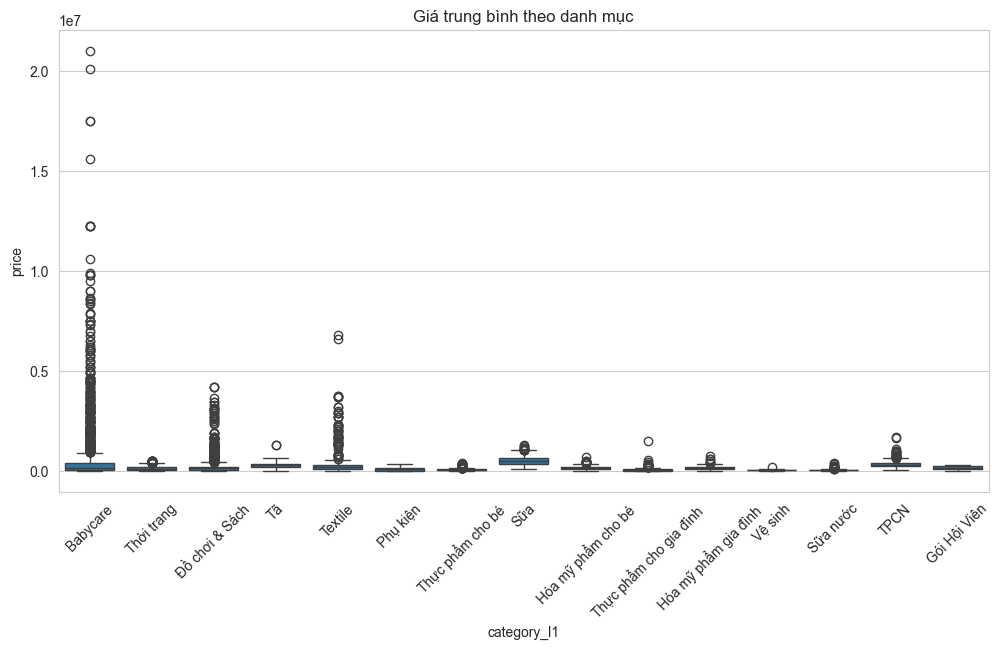

In [27]:
sns.boxplot(data=items_df, x='category_l1', y='price')
plt.xticks(rotation=45)
plt.title("Giá trung bình theo danh mục")
plt.show()

### **Số lượng sản phẩm mua theo membership**

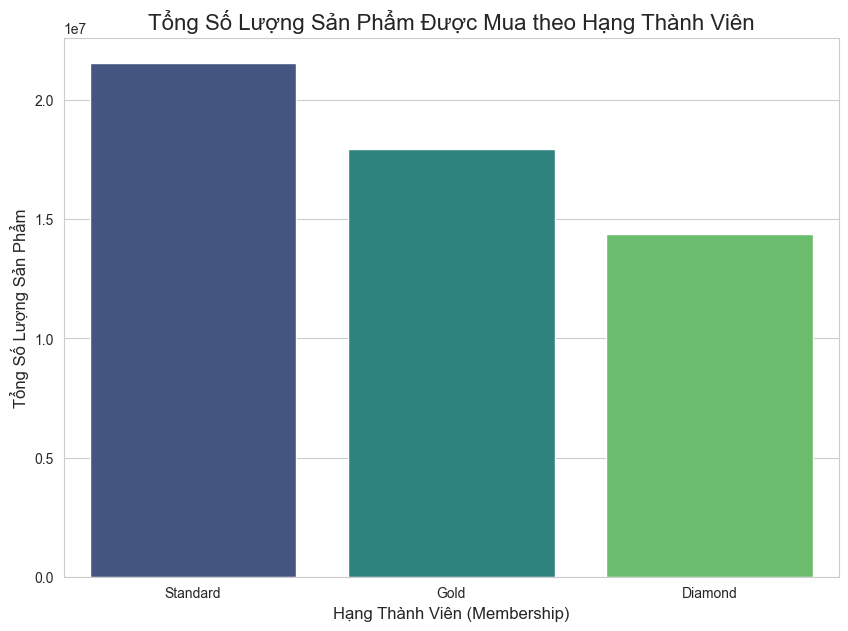

In [28]:
membership_quantity = df_full.groupby('membership')['quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=membership_quantity.index, y=membership_quantity.values, palette='viridis', hue=membership_quantity.index, legend=False)

# 3. Cải thiện tiêu đề và nhãn
plt.title('Tổng Số Lượng Sản Phẩm Được Mua theo Hạng Thành Viên', fontsize=16)
plt.xlabel('Hạng Thành Viên (Membership)', fontsize=12)
plt.ylabel('Tổng Số Lượng Sản Phẩm', fontsize=12)
plt.xticks(rotation=0) # Giữ cho nhãn trục x nằm ngang

plt.show()

### **Doanh thu theo thời gian**

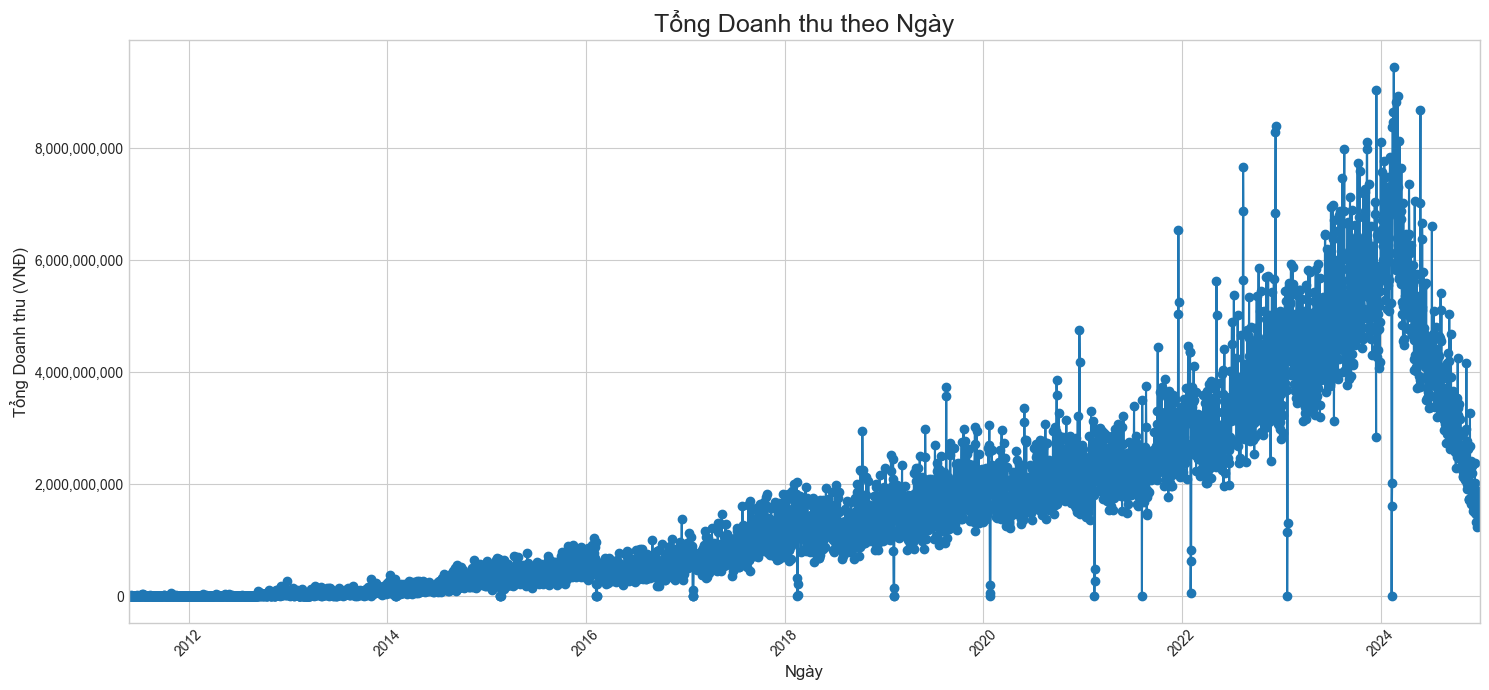

In [29]:
# 1. Đặt 'created_date' làm index để có thể resample
df_time = df_full.set_index('created_date')

# 2. Resample dữ liệu theo ngày ('D') và tính tổng 'total_price'
daily_revenue = df_time['total_price'].resample('D').sum()

# 3. Vẽ biểu đồ đường
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))
daily_revenue.plot(kind='line', marker='o', linestyle='-')

# 4. Cải thiện tiêu đề và nhãn
plt.title('Tổng Doanh thu theo Ngày', fontsize=18)
plt.xlabel('Ngày', fontsize=12)
plt.ylabel('Tổng Doanh thu (VNĐ)', fontsize=12)
# Tự động định dạng lại số trên trục y cho dễ đọc
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### **Phân Bổ Người Dùng theo vùng**

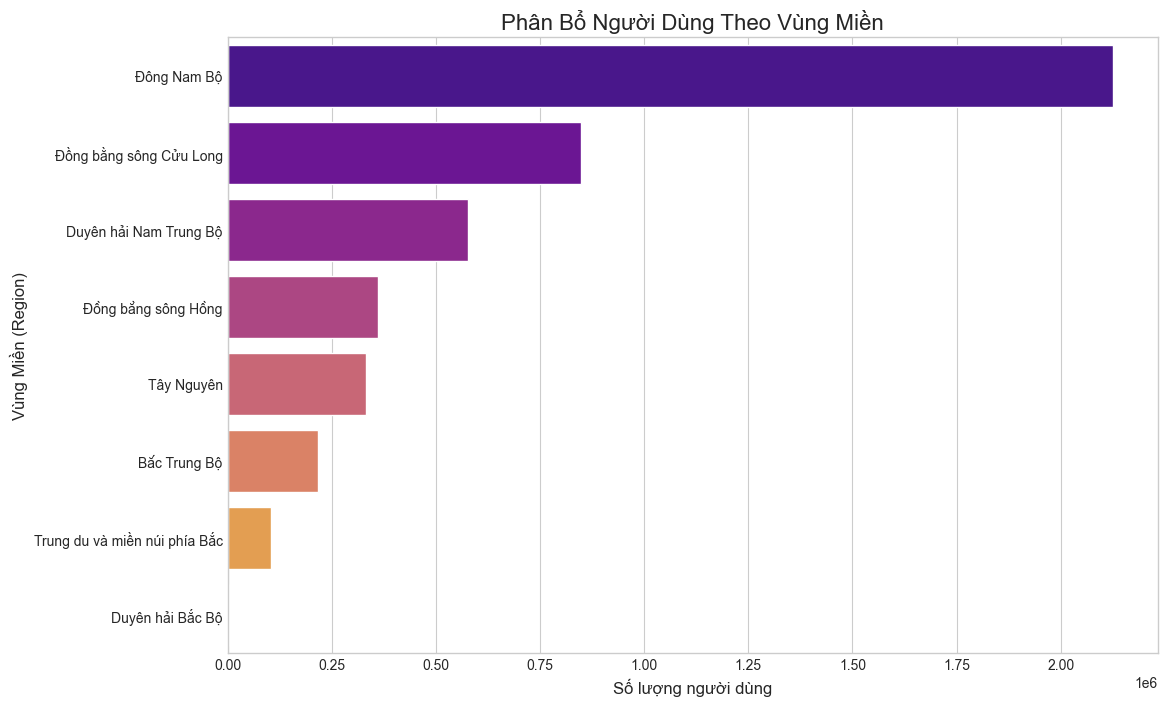

In [31]:
# 1. Đếm số lượng người dùng cho mỗi 'region'
region_counts = users_df['region'].value_counts()

# 2. Vẽ biểu đồ cột (chọn biểu đồ cột ngang để dễ đọc tên các vùng miền)
plt.figure(figsize=(12, 8))
sns.barplot(y=region_counts.index, x=region_counts.values, palette='plasma', hue=region_counts.index, legend=False)

# 3. Cải thiện tiêu đề và nhãn
plt.title('Phân Bổ Người Dùng Theo Vùng Miền', fontsize=16)
plt.xlabel('Số lượng người dùng', fontsize=12)
plt.ylabel('Vùng Miền (Region)', fontsize=12)

plt.show()